In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import shap

print("✅ Libraries imported!")
print(f"   SHAP version: {shap.__version__}")

C:\Users\iamsa\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Libraries imported!
   SHAP version: 0.52.0


In [2]:
# Load best model (XGBoost)
with open('../models/best_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('../models/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

with open('../models/symptom_columns.pkl', 'rb') as f:
    symptom_cols = pickle.load(f)

# Load test data
X_test = pd.read_pickle('../data/processed/X_test.pkl')
y_test = np.load('../data/processed/y_test.npy')

print("✅ All files loaded!")
print(f"   Model    : XGBoost")
print(f"   Features : {len(symptom_cols)}")
print(f"   Diseases : {len(le.classes_)}")
print(f"   Test rows: {X_test.shape[0]:,}")

✅ All files loaded!
   Model    : XGBoost
   Features : 270
   Diseases : 49
   Test rows: 12,416


In [3]:
print("⏳ Building SHAP explainer for XGBoost...")

# TreeExplainer works natively with XGBoost
explainer = shap.TreeExplainer(model)

# Use a small sample to keep it fast
X_sample = X_test.iloc[:100]

# For XGBoost multiclass, shap_values returns an array of shape:
#   (n_samples, n_features, n_classes)
shap_values = explainer.shap_values(X_sample)

print("✅ SHAP explainer built!")
print(f"   SHAP values type  : {type(shap_values)}")
print(f"   SHAP values shape : {np.array(shap_values).shape}")
print(f"   Rows explained    : {X_sample.shape[0]}")
print(f"   Classes           : {len(le.classes_)}")

⏳ Building SHAP explainer for XGBoost...
✅ SHAP explainer built!
   SHAP values type  : <class 'numpy.ndarray'>
   SHAP values shape : (100, 270, 49)
   Rows explained    : 100
   Classes           : 49


In [4]:
# shap_values shape: (n_samples, n_features, n_classes)
shap_array = np.array(shap_values)

# Average absolute SHAP across samples AND classes → per-feature importance
mean_shap = np.mean(np.abs(shap_array), axis=(0, 2))  # → (n_features,)

importance_df = pd.DataFrame({
    'feature'    : symptom_cols,
    'importance' : mean_shap
}).sort_values('importance', ascending=False)

print("=== Top 20 Most Important Features (Global) ===\n")
print(importance_df.head(20).to_string(index=False))

=== Top 20 Most Important Features (Global) ===

     feature  importance
        E_53    0.614636
         AGE    0.261667
E_54_@_V_179    0.257390
E_54_@_V_161    0.226008
E_54_@_V_192    0.222959
        E_66    0.206076
E_54_@_V_183    0.183079
E_54_@_V_181    0.138863
E_54_@_V_154    0.131649
        E_50    0.126672
        E_45    0.125030
 E_54_@_V_71    0.102597
        E_51    0.098758
         E_9    0.091676
E_54_@_V_112    0.089342
       E_194    0.086783
         E_3    0.077734
E_54_@_V_180    0.073780
E_54_@_V_198    0.071111
E_54_@_V_182    0.068412


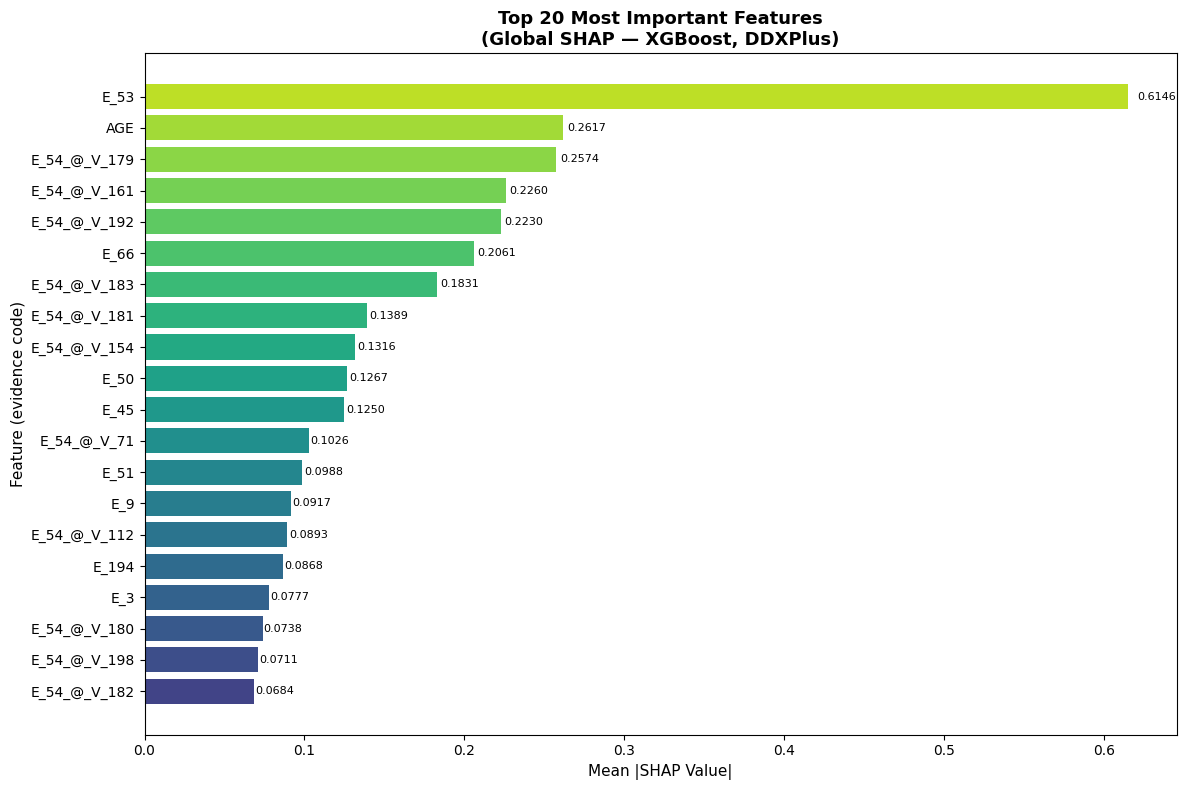

✅ Global importance chart saved!


In [5]:
top20 = importance_df.head(20)

plt.figure(figsize=(12, 8))
bars = plt.barh(
    top20['feature'][::-1],
    top20['importance'][::-1],
    color=plt.cm.viridis(np.linspace(0.2, 0.9, 20))
)

for bar, val in zip(bars, top20['importance'][::-1]):
    plt.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=8)

plt.title('Top 20 Most Important Features\n(Global SHAP — XGBoost, DDXPlus)',
          fontsize=13, fontweight='bold')
plt.xlabel('Mean |SHAP Value|', fontsize=11)
plt.ylabel('Feature (evidence code)', fontsize=11)
plt.tight_layout()
plt.savefig('../models/shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Global importance chart saved!")

In [6]:
sample_index  = 0
single_sample = X_sample.iloc[[sample_index]]

# Predict
predicted_encoded = int(model.predict(single_sample)[0])
predicted_disease = le.inverse_transform([predicted_encoded])[0]
actual_disease    = le.inverse_transform([int(y_test[sample_index])])[0]

print("=== Single Prediction Explanation ===")
print(f"   Actual Disease    : {actual_disease}")
print(f"   Predicted Disease : {predicted_disease}")
print(f"   Match             : {'✅ Correct' if actual_disease == predicted_disease else '❌ Wrong'}")

# Active features for this patient (value = 1)
active_features = [col for col in symptom_cols
                   if single_sample[col].values[0] == 1]
print(f"\n   Active evidences ({len(active_features)}):")
for s in active_features:
    print(f"     • {s}")

=== Single Prediction Explanation ===
   Actual Disease    : SLE
   Predicted Disease : SLE
   Match             : ✅ Correct

   Active evidences (5):
     • E_53
     • E_54_@_V_161
     • E_54_@_V_192
     • E_89
     • SEX_M


In [7]:
# For XGBoost: shap_values[sample_index][:, class_index] → per-feature contributions
single_shap = shap_array[sample_index][:, predicted_encoded]  # (n_features,)

shap_df = pd.DataFrame({
    'feature'    : symptom_cols,
    'shap_value' : single_shap,
    'active'     : single_sample.values[0]
})

# Only show features this patient actually has
shap_df = shap_df[shap_df['active'] == 1].copy()
shap_df = shap_df.sort_values('shap_value', ascending=False)

print(f"=== SHAP Contributions for: {predicted_disease} ===\n")
print(shap_df[['feature', 'shap_value']].to_string(index=False))

=== SHAP Contributions for: SLE ===

     feature  shap_value
E_54_@_V_192    2.996378
        E_89    2.994210
E_54_@_V_161    1.612257
       SEX_M    0.006500
        E_53    0.000000


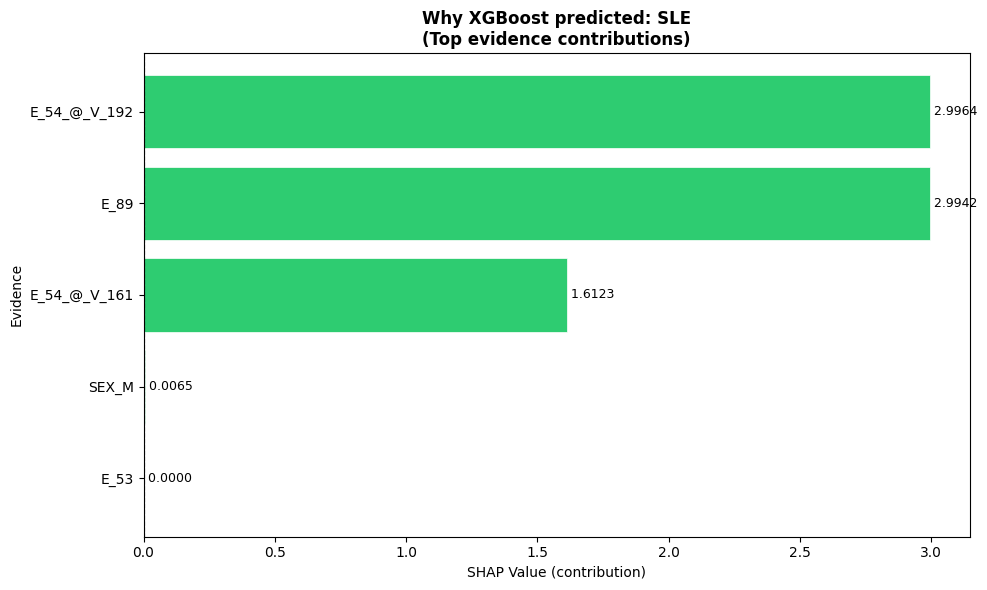

✅ Single prediction chart saved!


In [8]:
top_feats = shap_df.head(10)
colors    = ['#2ecc71' if v > 0 else '#e74c3c' for v in top_feats['shap_value']]

plt.figure(figsize=(10, 6))
bars = plt.barh(
    top_feats['feature'][::-1],
    top_feats['shap_value'][::-1],
    color=colors[::-1],
    edgecolor='white',
    linewidth=0.5
)

for bar, val in zip(bars, top_feats['shap_value'][::-1]):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f' {val:.4f}', va='center', fontsize=9)

plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title(f'Why XGBoost predicted: {predicted_disease}\n(Top evidence contributions)',
          fontsize=12, fontweight='bold')
plt.xlabel('SHAP Value (contribution)', fontsize=10)
plt.ylabel('Evidence', fontsize=10)
plt.tight_layout()
plt.savefig('../models/shap_single_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Single prediction chart saved!")

In [9]:
# This EXACT function logic will go into the Flask API
def predict_with_explanation(active_evidence_list: list) -> dict:
    """
    Input  : list of evidence codes the patient has (e.g. ['E_91', 'E_53'])
    Output : dict with disease prediction + SHAP explanation
    """
    # Build input vector (all features 0)
    input_vector = pd.DataFrame([{col: 0 for col in symptom_cols}])

    valid, invalid = [], []
    for ev in active_evidence_list:
        if ev in symptom_cols:
            input_vector[ev] = 1
            valid.append(ev)
        else:
            invalid.append(ev)

    # Predict
    predicted_encoded = int(model.predict(input_vector)[0])
    predicted_disease = le.inverse_transform([predicted_encoded])[0]
    probabilities     = model.predict_proba(input_vector)[0]
    confidence        = float(probabilities[predicted_encoded]) * 100

    # Top 3 alternative diagnoses
    top3 = np.argsort(probabilities)[::-1][:3]
    alternatives = [
        {"disease": le.inverse_transform([int(i)])[0],
         "probability": round(float(probabilities[i]) * 100, 2)}
        for i in top3
    ]

    # SHAP explanation for this prediction
    sv = explainer.shap_values(input_vector)
    sv = np.array(sv)[0][:, predicted_encoded]  # (n_features,)

    explanation = [
        {"feature": symptom_cols[i], "shap_value": round(float(sv[i]), 4)}
        for i in np.argsort(np.abs(sv))[::-1][:10]
        if input_vector.iloc[0][symptom_cols[i]] == 1
    ]

    return {
        "predicted_disease": predicted_disease,
        "confidence"       : round(confidence, 2),
        "valid_evidences"  : valid,
        "invalid_evidences": invalid,
        "alternatives"     : alternatives,
        "explanation"      : explanation
    }

print("✅ predict_with_explanation() function defined!")

✅ predict_with_explanation() function defined!


In [10]:
# Grab a real patient's active evidences from the test set to test with
test_patient    = X_test.iloc[5]
active_evidence = [col for col in symptom_cols if test_patient[col] == 1]

print(f"Testing with evidences: {active_evidence}\n")

result = predict_with_explanation(active_evidence)

print("=" * 50)
print("       PREDICTION RESULT")
print("=" * 50)
print(f"  Disease    : {result['predicted_disease']}")
print(f"  Confidence : {result['confidence']}%")
print(f"\n  Top 3 alternatives:")
for alt in result['alternatives']:
    print(f"    • {alt['disease']:<35} {alt['probability']}%")
print(f"\n  SHAP Explanation (why this disease?):")
for item in result['explanation']:
    bar = '█' * int(abs(item['shap_value']) * 30)
    print(f"    {item['feature']:<20} {item['shap_value']:+.4f}  {bar}")
print("=" * 50)

Testing with evidences: ['E_103', 'E_53', 'E_54_@_V_181', 'E_54_@_V_192', 'SEX_F']

       PREDICTION RESULT
  Disease    : Chronic rhinosinusitis
  Confidence : 80.64%

  Top 3 alternatives:
    • Chronic rhinosinusitis              80.64%
    • Acute rhinosinusitis                18.92%
    • PSVT                                0.06%

  SHAP Explanation (why this disease?):
    E_54_@_V_181         +2.5447  ████████████████████████████████████████████████████████████████████████████
    E_54_@_V_192         +0.8363  █████████████████████████
    E_103                +0.1643  ████


In [11]:
with open('../models/shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

print("=" * 50)
print("        ALL FILES SAVED ✅")
print("=" * 50)
print("  🧠 models/best_model.pkl        (XGBoost)")
print("  🔍 models/shap_explainer.pkl")
print("  🔧 models/label_encoder.pkl")
print("  🔧 models/symptom_columns.pkl")
print("  📊 models/shap_global_importance.png")
print("  📊 models/shap_single_prediction.png")
print("=" * 50)
print("\n🚀 Ready to update the Flask API!")

        ALL FILES SAVED ✅
  🧠 models/best_model.pkl        (XGBoost)
  🔍 models/shap_explainer.pkl
  🔧 models/label_encoder.pkl
  🔧 models/symptom_columns.pkl
  📊 models/shap_global_importance.png
  📊 models/shap_single_prediction.png

🚀 Ready to update the Flask API!
